# Object Detection com YOLOS (Hugging Face)

Este notebook realiza detecção de objetos em imagens usando o modelo `hustvl/yolos-small` do Hugging Face.

## 1. Instalação de Dependências

In [ ]:
# Instalar as bibliotecas necessárias
#!pip install transformers torch torchvision pillow matplotlib

  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   --------------- ------------------------ 4.2/10.7 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.7 MB 26.5 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 23.1 MB/s  0:00:00
   ---------------------------------------- 0.0/616.3 kB ? eta -:--:--
   ---------------------------------------- 616.3/616.3 kB 14.0 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 26.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 22.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------------------------- ------ 6.8/8.1 MB 32.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Rodrigo\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## 2. Importar Bibliotecas Necessárias

In [9]:
import os
import torch
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# Set device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


## 🛠️ Setup the Model and Processor
We'll load the pre-trained model and its corresponding image processor.

In [11]:
model_name = "hustvl/yolos-small"

processor = AutoImageProcessor.from_pretrained(model_name) 
model = AutoModelForObjectDetection.from_pretrained(model_name).to(device)  # Manda para o device

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 4221.32it/s]


## Processing Images
Let's define a function to perform detection and visualize the bounding boxes.

In [16]:
def detect_objects(imagens_path, thresold=0.9):
    # Load image
    image = Image.open(imagens_path).convert('RGB')

    # Prepare image for the model
    inputs = processor(images=image, return_tensors='pt').to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process detection
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=thresold)

    return image, results

def plot_results(image, result):
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.imshow(image)

    # Choose colors from a colormap
    colors = plt.cm.hsv(torch.linspace(0, 1, 91)).tolist()

    for score, label, box in zip(result['scores'], result["labels"], result["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        x, y, x2, y2 = box

        label_idx = label.item()
        color = colors[label_idx % len(colors)]

        # Draw bounding box 
        rect = plt.Rectangle((x, y), x2 - x, y2 - y, fill=False, color=color, linewidth=3)
        ax.add_patch(rect)

        # Annotate label and score
        label_name = model.config.id2label[label_idx]
        ax.text(x, y, f"{label_name}: {score:.2f}", fontsize=15,
                bbox=dict(facecolor=color, alpha=0.5, edgecolor='none', boxstyle='round'))
        
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Runnin Inference
Now we'll loop through all images in the `Imagens` folder and perform object detection


Processing: birds.png...


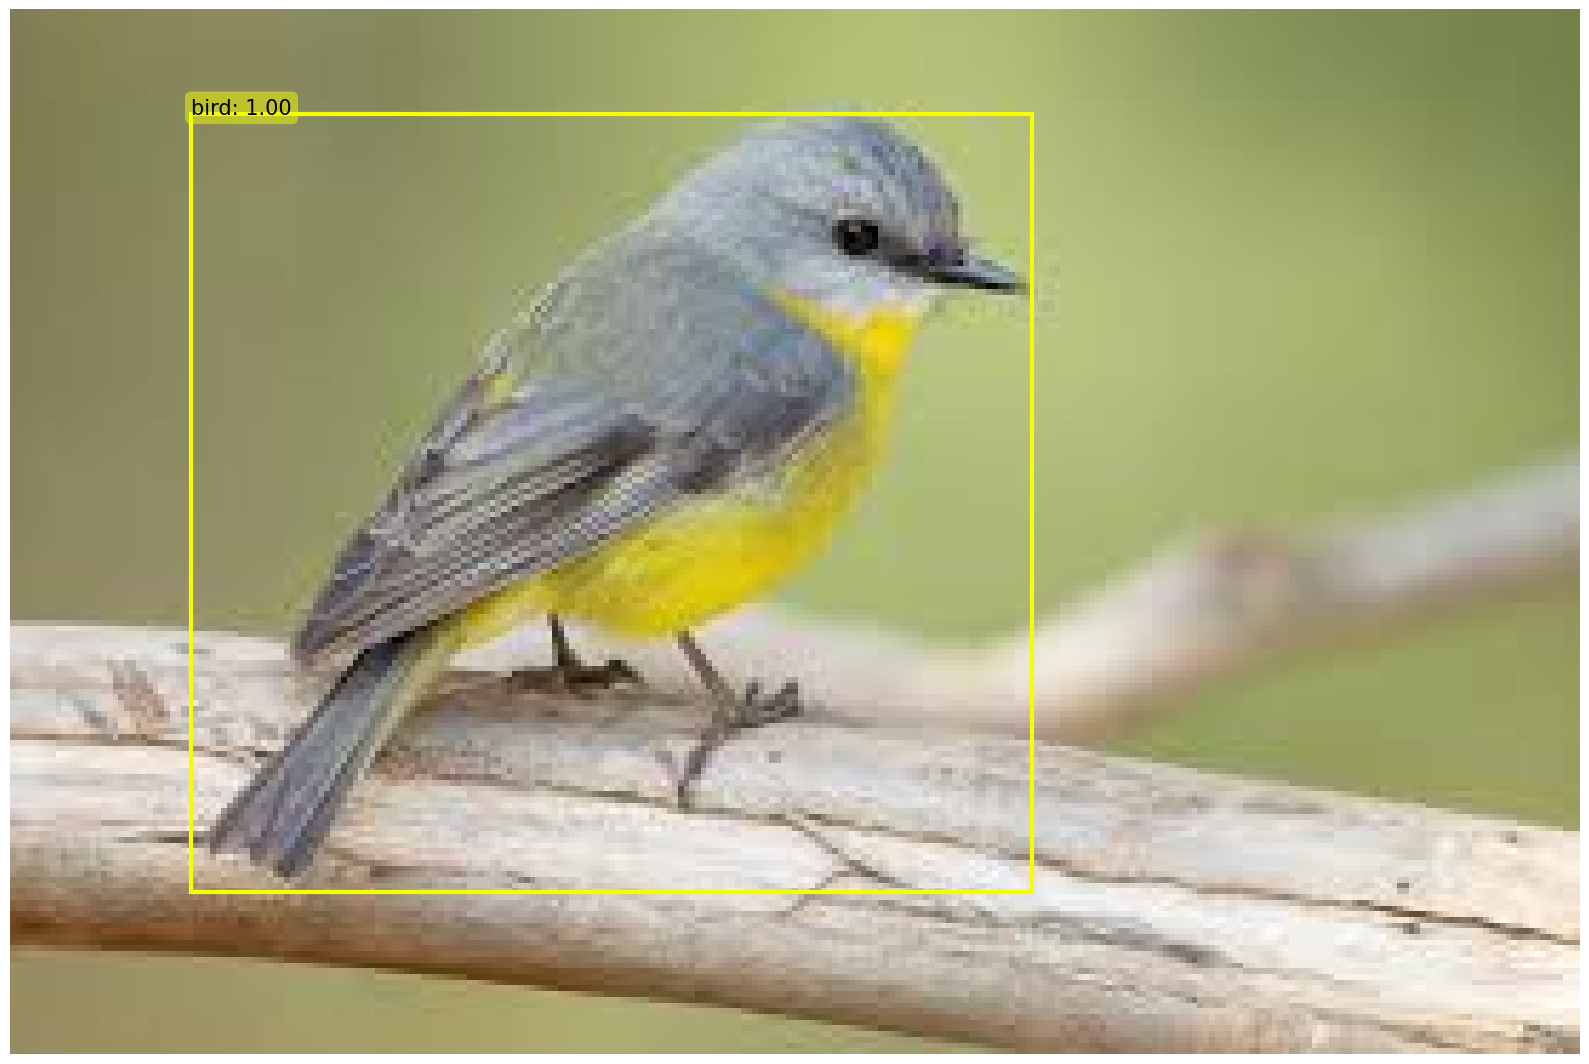


Processing: cats_dogs.png...


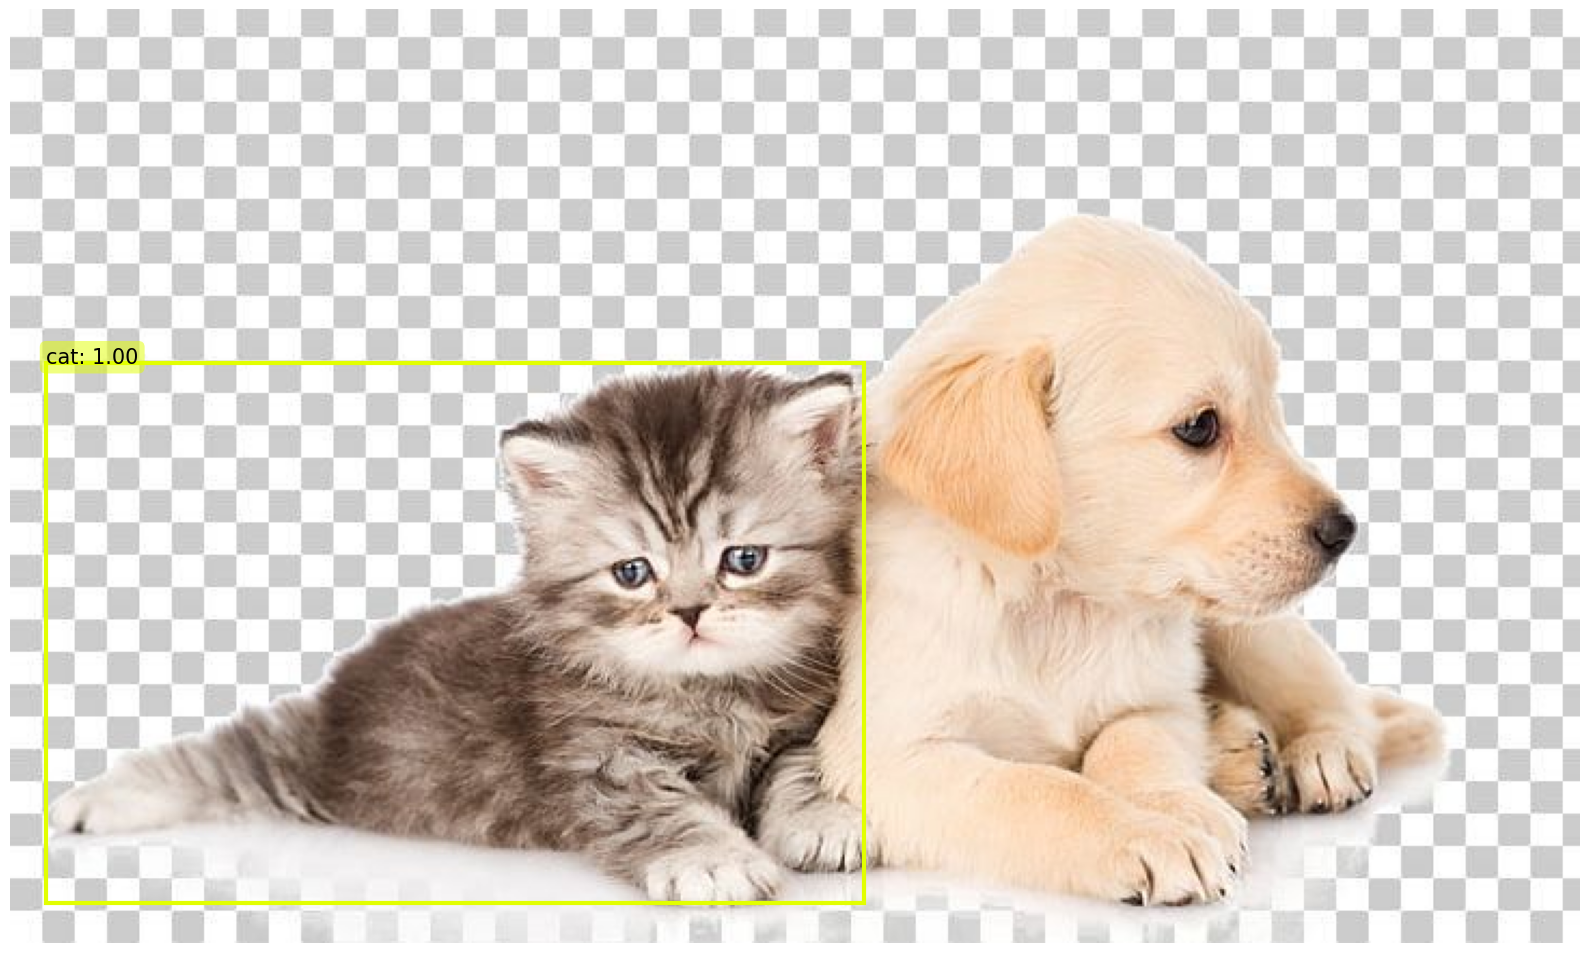


Processing: kitchen.png...


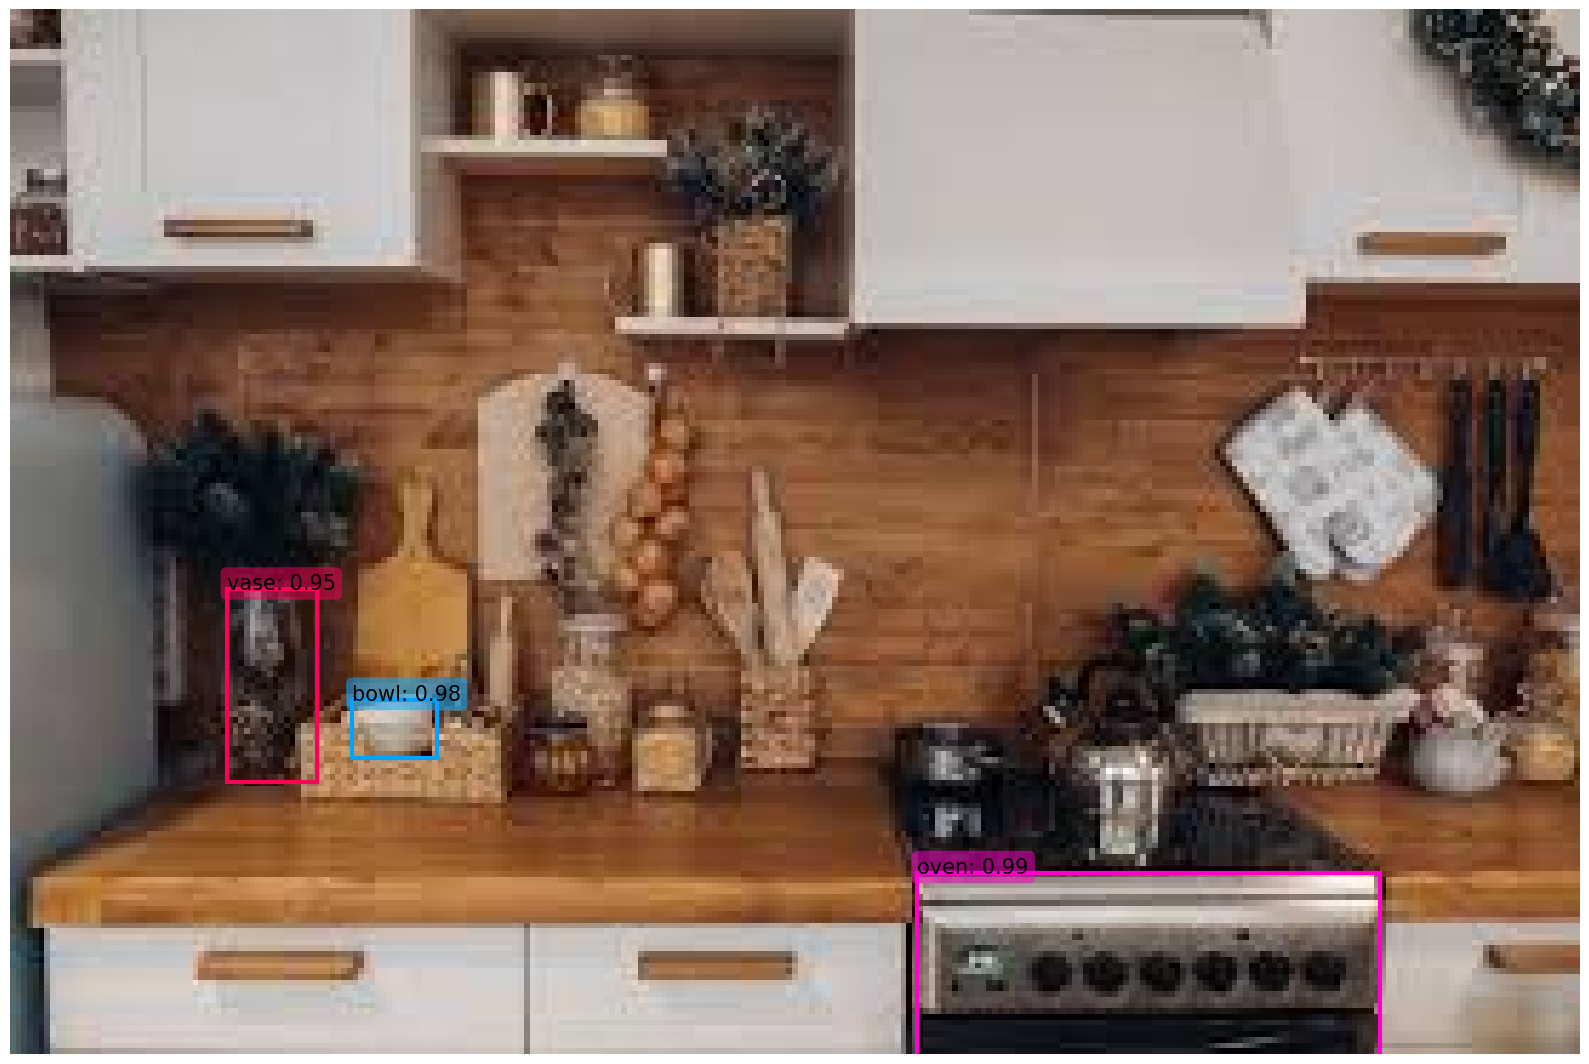


Processing: pizza.png...


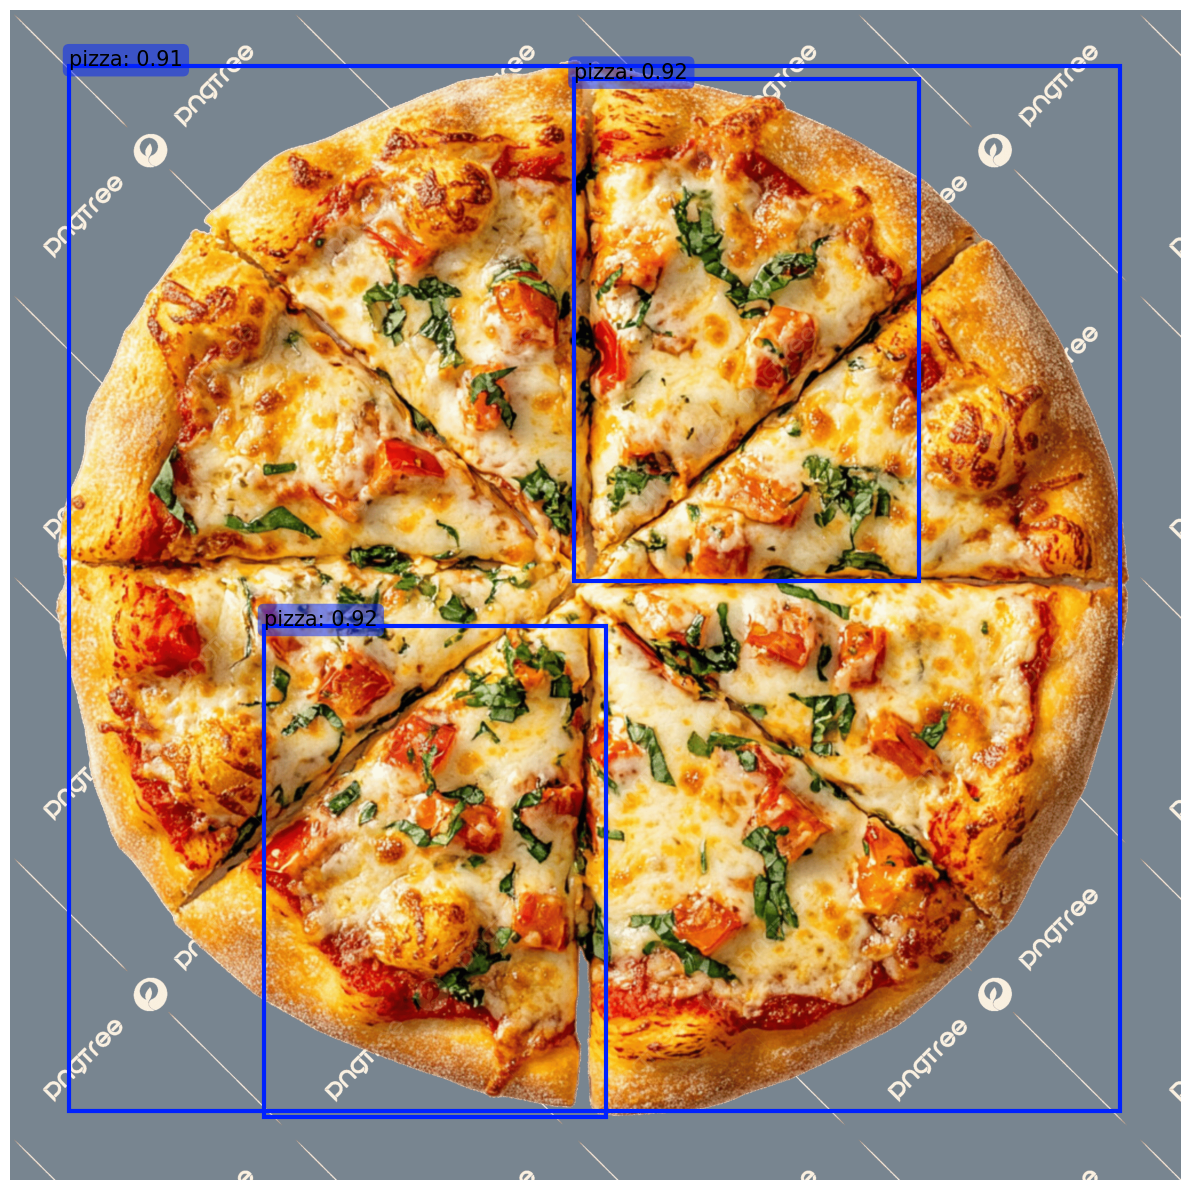

In [21]:
image_folder = Path("imagens")
image_files = sorted([f for f in image_folder.iterdir() if f.suffix.lower() in ('.png', '.jpg', '.jpeg')])

for img_file in image_files:
    print(f"\nProcessing: {img_file.name}...")

    image, results = detect_objects(str(img_file))

    if len(results[0]["scores"]) == 0:
        print(f"No objects detected in {img_file.name} above the threshold.")
        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        plt.title(f"{img_file.name} (No detections)")
        plt.axis("off")
        plt.show()
    else:
        plot_results(image, results[0])

## 6. Processar Todas as Imagens

In [18]:
# Definir o limiar de confiança
confidence_threshold = 0.5

# Processar cada imagem
for image_file in image_files:
    try:
        print(f"\nProcessando: {image_file.name}...")
        
        # Detectar objetos
        image, detections = detect_objects(image_file, confidence_threshold)
        
        # Exibir informações
        print_detections(detections, image_file.name)
        
        # Visualizar
        visualize_detections(image, detections, f"Detecção de Objetos - {image_file.name}")
        
    except Exception as e:
        print(f"Erro ao processar {image_file.name}: {str(e)}")


Processando: birds.png...
Erro ao processar birds.png: name 'print_detections' is not defined

Processando: cats_dogs.png...
Erro ao processar cats_dogs.png: name 'print_detections' is not defined

Processando: kitchen.png...
Erro ao processar kitchen.png: name 'print_detections' is not defined

Processando: pizza.png...
Erro ao processar pizza.png: name 'print_detections' is not defined


## 7. Detecção Individual (Opcional)

In [ ]:
# Processar uma imagem específica com diferentes limiares de confiança
image_to_analyze = image_files[0]  # Primeira imagem

print(f"Analisando: {image_to_analyze.name}")
print("\nResultados com diferentes limiares de confiança:")
for threshold in [0.3, 0.5, 0.7]:
    image, detections = detect_objects(image_to_analyze, threshold)
    num_detections = len(detections)
    print(f"  Limiar {threshold}: {num_detections} objetos detectados")